## Beyond A/B Testing: Measuring True Impact When Users Don't Comply

Imagine your company launches an A/B test for a new website feature, like a premium membership. Group A visists the old site, and Group B gets an invitation to join the new program. The problem is that we can't *force* users in Group B to accept the invitation. This is called **imperfect compliance**, and it makes measuring the true impact of membership tricky.

If we simply compare Group B to Group A, we're measuring the effect of the *invitation*, not the membership itself. If we only compare the members to non-members, we introduce **selection bias**—the users who chose to sign up were likely more engaged to begin with\!

This tutorial tackles this common and complex causal inference problem: **How do we measure the true effect of a treatment when we can't control who takes the treatment?** We will use an **Instrumental Variable (IV)** method within an **Intent-to-Treat** framework. The core idea is to use a random "nudge"—an encouragement that affects the treatment but not the outcome—to isolate the true, unbiased effect of the action.

In this task, we will apply **Python** and Microsoft's [**EconML**](https://github.com/py-why/EconML) library to implement a state-of-the-art causal machine learning system with the following steps:

  * Understand the challenge of **imperfect compliance** and **selection bias** in experiments.
  * Frame a problem using an **Instrumental Variable (IV)** and an **Intent-to-Treat** approach.
  * Train an EconML model (`LinearIntentToTreatDRIV`) to estimate **heterogeneous treatment effects**.
  * **Evaluate the model's accuracy** by comparing its findings to a known ground truth.
  * Use interpretability tools to **discover rules** about which users respond best to treatment.
  * Translate causal insights into a **data-driven policy** for targeted interventions.

**Credits**

This tutorial is adapted from the official EconML tutorial on [handling imperfect compliance](https://github.com/py-why/EconML/blob/main/notebooks/CustomerScenarios/Case%20Study%20-%20Recommendation%20AB%20Testing%20at%20An%20Online%20Travel%20Company.ipynb).

To protect user privacy, the dataset is synthetically generated to mirror a real-world scenario. While the feature distributions are not real, the feature names and the underlying causal problem are preserved. The data is hosted by the Py-Why EconML team in their [examples repository](https://raw.githubusercontent.com/py-why/EconML/refs/heads/data/datasets/RecommendationAB/ab_sample.csv).

**Compatibility**

This tutorial uses a small dataset and standard Python libraries, making it compatible with most environments.

| Platform                     | Compatible | Recommended | Notes                                                                   |
| :--------------------------- | :--------: | :---------: | :---------------------------------------------------------------------- |
| **Local (e.g., MacBook/PC)** |   ✅ Yes   |    ✅ Yes   | Perfect for learning. The dataset is small and runs instantly.          |
| **Google Colab** |   ✅ Yes   |    ✅ Yes   | An excellent option. Requires installing EconML: `pip install econml`. |
| **Midway/HPC Clusters** |   ✅ Yes   |    ✅ Yes   | Works well. Requires installing EconML: `pip install econml`.           |



### Setting Up the Task: The Travel Website

A travel website wants to know if its membership program causes users to visit the site more often. A previous experiment was run where a random group of users was shown a new, faster sign-up process. This "nudge" is our key to unlocking the problem.

  * **The Treatment (T):** Becoming a member (`became_member`). This is the action whose effect we want to measure.
  * **The Instrument (Z):** Being shown the easier sign-up process (`easier_signup`). This is our random nudge. It encourages users to become members, but it shouldn't *directly* make them visit the site more.
  * **The Outcome (Y):** The number of days a user visits the site *after* the experiment (`days_visited_post`).
  * **The Features (X):** User characteristics known before the experiment (e.g., `revenue_pre`, `os_type`).

The `LinearIntentToTreatDRIV` estimator will use the random assignment of the instrument **Z** to untangle the biased relationship between the user's choice to get treatment **T** and the final outcome **Y**.

#### **Imports and Data Loading**

First, let's import the necessary libraries and load our data.

In [ ]:
# Install dependencies
%pip install lightgbm==4.6.0 econml==0.16.0

In [ ]:
# Utilities
import numpy as np
import pandas as pd

# Generic ML imports
import lightgbm as lgb
from sklearn.preprocessing import PolynomialFeatures

# EconML imports
from econml.iv.dr import LinearIntentToTreatDRIV
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Run this to retrieve the data on Colab
!wget https://raw.githubusercontent.com/py-why/EconML/refs/heads/data/datasets/RecommendationAB/ab_sample.csv
!mkdir ab_sample
!mv ab_sample.csv ab_sample

In [ ]:
# Import the sample AB data
file_path = "ab_sample/ab_sample.csv"
ab_data = pd.read_csv(file_path)
ab_data.head()

,days_visited_exp_pre,days_visited_free_pre,days_visited_fs_pre,days_visited_hs_pre,days_visited_rs_pre,days_visited_vrs_pre,locale_en_US,revenue_pre,os_type_osx,os_type_windows,easier_signup,became_member,days_visited_post
0,1,9,7,25,6,3,1,0.01,0,1,0,0,1
1,10,25,27,10,27,27,0,2.26,0,0,0,0,15
2,18,14,8,4,5,2,1,0.03,0,1,0,0,17
3,17,0,23,2,3,1,1,418.77,0,1,0,0,6
4,24,9,22,2,3,18,1,1.54,0,0,0,0,12


The data includes features from before the experiment (`_pre`), the experiment variables, and the outcome measured after (`_post`).

#### **Defining Inputs for EconML**

Now, we'll assign our columns to their causal roles: **Z** (instrument), **T** (treatment), **Y** (outcome), and **X** (features).

In [ ]:
# Define estimator inputs
Z = ab_data['easier_signup'] # nudge, or instrument
T = ab_data['became_member'] # intervention, or treatment
Y = ab_data['days_visited_post'] # outcome of interest
X_data = ab_data.drop(columns=['easier_signup', 'became_member', 'days_visited_post']) # features

#### **The "Answer Key": Ground Truth**

Because our data is synthetic, we have a unique advantage: we know the *true* underlying treatment effect function that was used to generate the data. This acts as an "answer key" to validate our model's performance.

$$\text{treatment_effect} = 0.2 + 0.3 \cdot \text{days_visited_free_pre} - 0.2 \cdot \text{days_visited_hs_pre} + \text{os_type_osx}$$

The formula shows that users who visited through free channels or use OSX benefit most from membership, while users who previously visited hotel pages are harmed. Our goal is to explore **whether EconML can learn this relationship from the biased data.**

In [ ]:
# Define underlying treatment effect function
def TE_fn(X):
    return (0.2 + 0.3 * X["days_visited_free_pre"] - 0.2 * X["days_visited_hs_pre"] + X["os_type_osx"]).values
true_TE = TE_fn(X_data)

# Define the true coefficients to compare with
true_coefs = np.zeros(X_data.shape[1])
true_coefs[[1, 3, -2]] = [0.3, -0.2, 1]

-----

### Finding the Cause: Training a Causal Model

The `LinearIntentToTreatDRIV` estimator needs a few helper machine learning models, called **nuisance models**, to isolate the causal effect from all the other patterns in the data. We'll use LightGBM for this.

In [ ]:
# Define nuissance estimators
lgb_T_XZ_params = {'objective' : 'binary', 'metric' : 'auc', 'learning_rate': 0.1, 'num_leaves' : 30, 'max_depth' : 5}
lgb_Y_X_params = {'metric' : 'rmse', 'learning_rate': 0.1, 'num_leaves' : 30, 'max_depth' : 5}

model_T_XZ = lgb.LGBMClassifier(**lgb_T_XZ_params)
model_Y_X = lgb.LGBMRegressor(**lgb_Y_X_params)
flexible_model_effect = lgb.LGBMRegressor(**lgb_Y_X_params)

# Train EconML model
model = LinearIntentToTreatDRIV(
    model_y_xw = model_Y_X,
    model_t_xwz = model_T_XZ,
    flexible_model_effect = flexible_model_effect,
    featurizer = PolynomialFeatures(degree=1, include_bias=False)
)
model.fit(Y, T, Z=Z, X=X_data, inference="statsmodels")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 10
[LightGBM] [Info] Start training from score 9.952170
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 10
[LightGBM] [Info] Start training from score 2.718645
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 66666, number of used features: 10
[LightGBM] [Info] Start training from score 9.998770
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 66667, number of used features: 10
[LightGBM] [Info] Start training from score 9.900880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011821 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 435
[LightGBM] [Info] Number of data points in the train set: 66667, number of used features: 10
[LightGBM] [Info] Start training from score 2.679311
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils

**How it Works:** The `model.fit()` call orchestrates a multi-stage estimation process. It uses the nuisance models to predict the outcome and treatment based on features, then uses the **instrument (Z)** to correct for the bias and learn the true linear relationship between the features **X** and the treatment effect.

-----

### Did it Work? Evaluating the Model's Insights

Now, let's evaluate the model performance by comparing its learned coefficients to the "answer key."

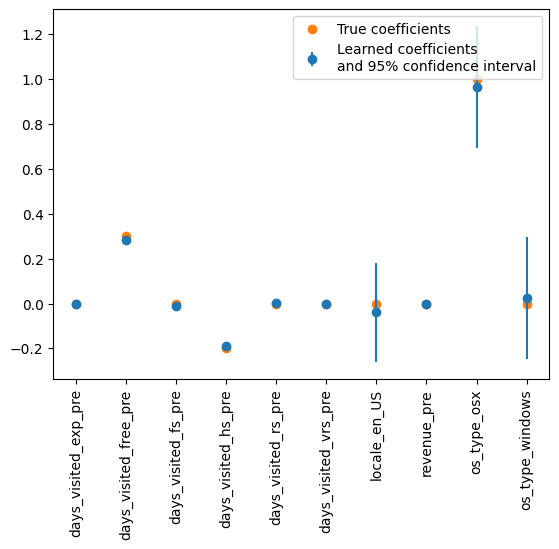

In [ ]:
# Compare learned coefficients with true model coefficients
coef_indices = np.arange(model.coef_.shape[0])
# Calculate error bars
coef_error = np.asarray(model.coef__interval()) # 95% confidence interval for coefficients
coef_error[0, :] = model.coef_ - coef_error[0, :]
coef_error[1, :] = coef_error[1, :] - model.coef_

plt.errorbar(coef_indices, model.coef_, coef_error, fmt="o", label="Learned coefficients\nand 95% confidence interval")
plt.scatter(coef_indices, true_coefs, color='C1', label="True coefficients")
plt.xticks(coef_indices, X_data.columns, rotation='vertical')
plt.legend()
plt.show()

**Analysis:** The learned coefficients (blue dots) are very close to the true coefficients (orange dots), and the 95% confidence intervals contain the true values for the most important features. This shows our model successfully recovered the underlying causal structure.

The `summary()` method gives us a statistical table with p-values and confidence intervals.

In [ ]:
model.summary()

,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
days_visited_exp_pre,-0.0,0.007,-0.064,0.949,-0.014,0.013
days_visited_free_pre,0.285,0.007,38.384,0.0,0.271,0.3
days_visited_fs_pre,-0.009,0.007,-1.312,0.19,-0.022,0.004
days_visited_hs_pre,-0.19,0.007,-27.998,0.0,-0.203,-0.176
days_visited_rs_pre,0.001,0.007,0.166,0.868,-0.012,0.014
days_visited_vrs_pre,-0.0,0.007,-0.036,0.972,-0.013,0.013
locale_en_US,-0.04,0.113,-0.351,0.726,-0.262,0.182
revenue_pre,-0.0,0.0,-1.006,0.315,-0.0,0.0
os_type_osx,0.964,0.139,6.938,0.0,0.691,1.236
os_type_windows,0.025,0.138,0.18,0.857,-0.246,0.296


**Analysis:** As expected, the model correctly identifies **`days_visited_free_pre`**, **`days_visited_hs_pre`**, and **`os_type_osx`** as the only statistically significant drivers of the treatment effect (p-value \< 0.05).

Finally, let's check how well the model predicts the effect for individual users.

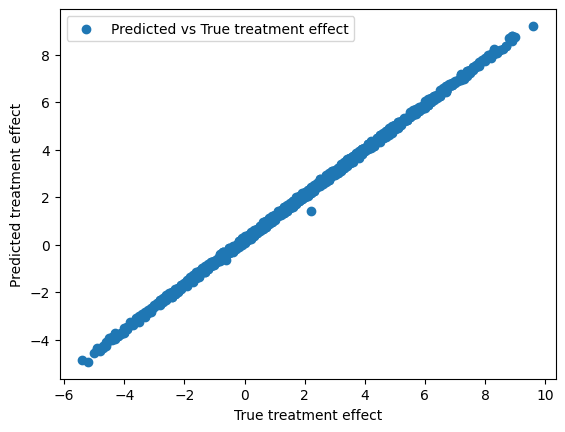

In [ ]:
test_customers = X_data.iloc[:1000]
true_customer_TE = TE_fn(test_customers)
model_customer_TE = model.effect(test_customers)

plt.scatter(true_customer_TE, model.effect(test_customers), label="Predicted vs True treatment effect")
plt.xlabel("True treatment effect")
plt.ylabel("Predicted treatment effect")
plt.legend()
plt.show()

**Analysis:** The strong linear relationship in the scatter plot confirms that the model's predictions are highly correlated with the true effects at the individual user level.

-----

### From Numbers to Rules: Understanding Who Responds Best

An equation is useful, but a simple set of rules is often more actionable. EconML's `SingleTreeCateInterpreter` trains a simple decision tree to explain our complex model's predictions.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has fe

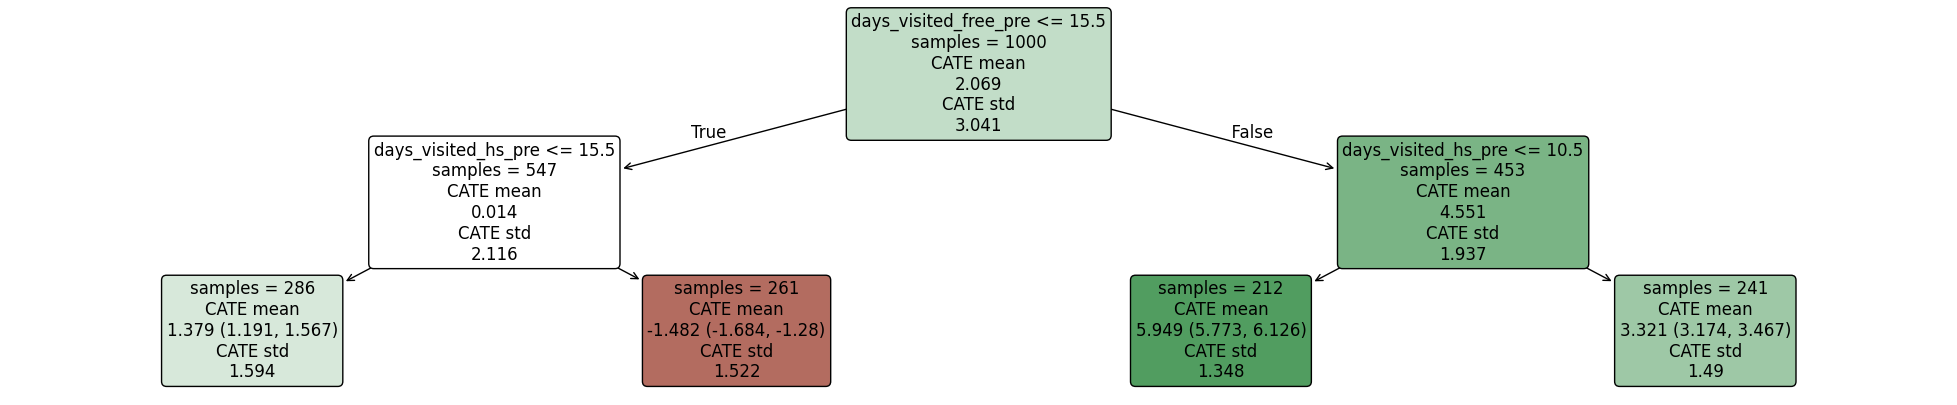

In [ ]:
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=2, min_samples_leaf=10)
intrp.interpret(model, test_customers)
plt.figure(figsize=(25, 5))
intrp.plot(feature_names=X_data.columns, fontsize=12)

**How to Read the Tree:** The tree segments users based on their features. The leaves show the predicted treatment effect, with dark green indicating a strong positive response and dark red indicating a negative response. For example, the far-right leaf tells us that users with `os_type_osx > 0.5` (OSX users) are predicted to have a very strong positive response to membership.

### Making Smart Decisions: From Insights to Policy

Usually, encouraging users comes with a cost (e.g., a sign-up discount). We only want to target users where the benefit from their increased engagement outweighs that cost. The `SingleTreePolicyInterpreter` helps us learn these optimal targeting rules.

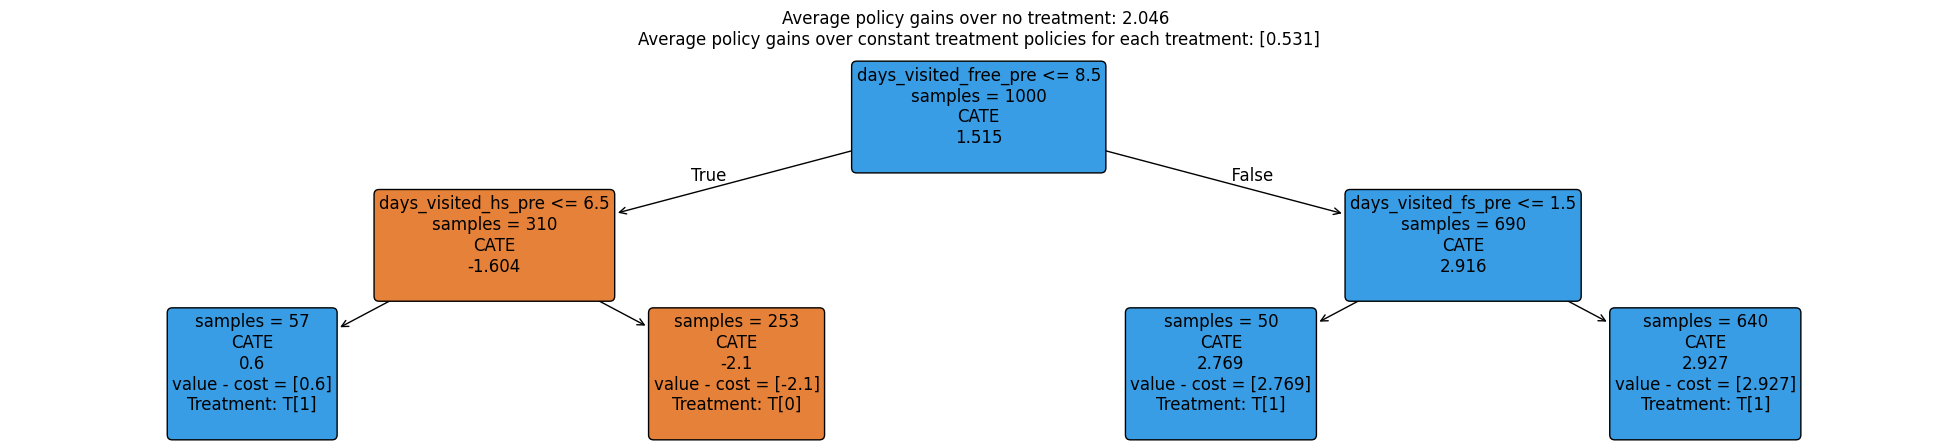

In [ ]:
intrp = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=2, min_samples_leaf=10)
intrp.interpret(model, test_customers, sample_treatment_costs=0.2)
plt.figure(figsize=(25, 5))
intrp.plot(feature_names=X_data.columns, fontsize=12)

**How to Read the Policy Tree:** Assuming it costs $0.20 to encourage a user, the tree tells us whom to target to. Users in the green "TREAT" leaves are those for whom the predicted benefit of membership is greater than the cost. This provides a simple, data-driven policy for maximizing profit.

### Conclusion

In this tutorial, we navigated a challenging but common real-world scenario where simple A/B testing fails. By using an Instrumental Variable approach with EconML, we were able to:

  * **Estimate a valid causal effect** despite imperfect compliance and selection bias.
  * **Interpret the model** to understand which user characteristics drive heterogeneous effects.
  * **Build an optimal policy** for targeting users to maximize returns.

These techniques move beyond traditional machine learning to answer not just "what will happen," but "what should we do"—providing a powerful toolkit for data-driven decision-making.

To learn more about EconML, visit the [EconML website](https://aka.ms/econml) and [GitHub page](https://github.com/py-why/EconML).